# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [52]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [53]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [54]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [55]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"))
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"))
    X_test = np.loadtxt(os.path.join(root_dir, "test", "X_test.txt"))
    y_test = np.loadtxt(os.path.join(root_dir, "test", "y_test.txt"))
    y_train -= 1
    y_test -= 1

    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# define num_features and num_classes
num_features = X_train.shape[1]
num_classes = len(class_names)


## 5. Quick Inspection


In [56]:
# Create a small summary table showing the class index, class name, and number of training samples.

class_counts = pd.Series(y_train).value_counts().sort_index()
summary_table = pd.DataFrame({
    'Class Index': range(num_classes),
    'Class Name': class_names,
    'Training Samples': [class_counts[i] for i in range(num_classes)]
})
print(summary_table)

   Class Index          Class Name  Training Samples
0            0             WALKING              1226
1            1    WALKING_UPSTAIRS              1073
2            2  WALKING_DOWNSTAIRS               986
3            3             SITTING              1286
4            4            STANDING              1374
5            5              LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [57]:
def build_baseline_model(input_dim, num_classes):
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential([
        layers.Dense(256, activation='relu', input_shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 256)               143872    
                                                                 
 dense_13 (Dense)            (None, 128)               32896     
                                                                 
 dense_14 (Dense)            (None, 64)                8256      
                                                                 
 dense_15 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [58]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0748 - accuracy: 0.9711 - val_loss: 0.2056 - val_accuracy: 0.9313
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0765 - accuracy: 0.9716 - val_loss: 0.1482 - val_accuracy: 0.9443
Epoch 8/40
92/92 [==

### Training Curves


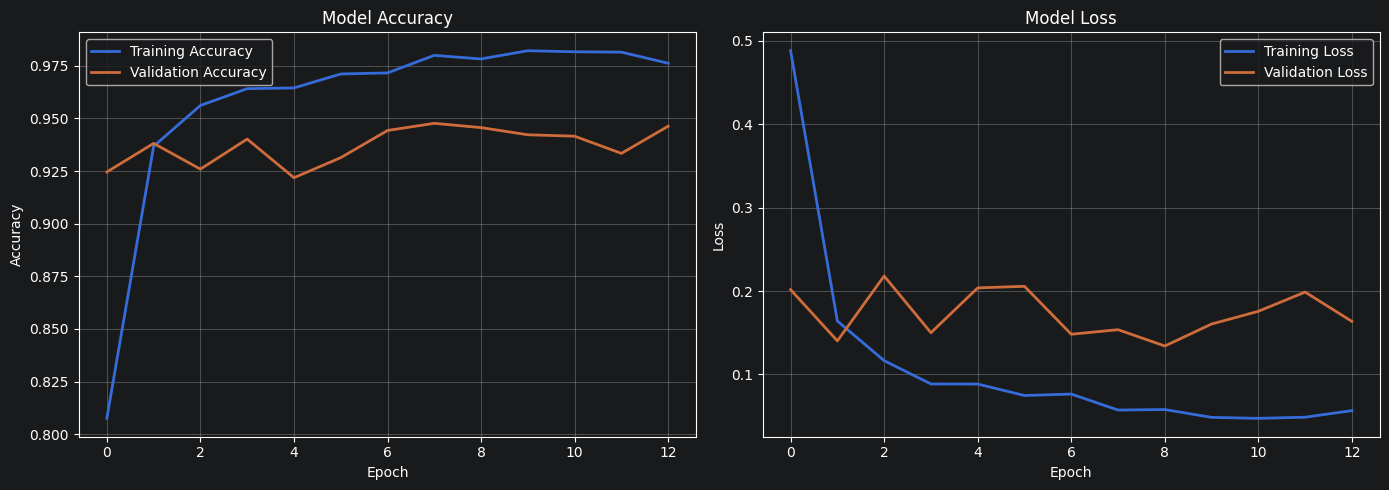

In [59]:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 1ms/step
Test Accuracy: 0.9220

Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.95      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



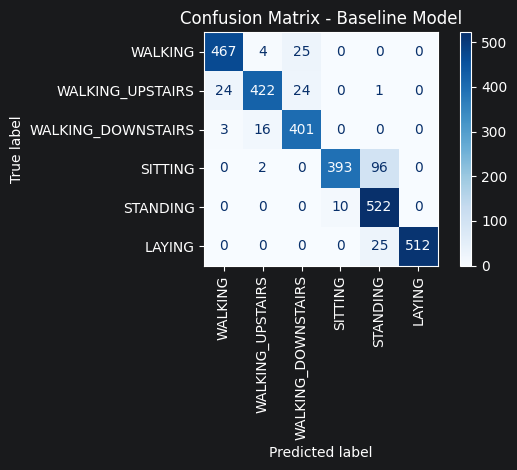

In [60]:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

probs = baseline_model.predict(X_test)
y_pred = np.argmax(probs, axis=1)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred, target_names=class_names)}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.show()

## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [61]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]

    # Randomly select 300 indices from training data
    num_samples = 300
    indices = np.random.choice(X_train.shape[0], num_samples, replace=False)

    for idx in indices:
        # Get the sample and reshape to [1, num_features] for batch dimension
        sample = X_train[idx:idx+1].astype(np.float32)
        yield [sample]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        if input_details["dtype"] in [np.int8, np.uint8]:
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # If the output is quantized, dequantize it back to float32.
        if output_details["dtype"] in [np.int8, np.uint8]:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # return the converted FP32 TensorFlow Lite model
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()


## 9. Post-Training Quantization (PTQ)


In [62]:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# Convert FP32 model
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
fp32_size = save_binary_model(tflite_fp32, "model_ptq_fp32.tflite")
fp32_acc, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)
print(f"FP32 Model - Size: {fp32_size:.2f} KB, Accuracy: {fp32_acc:.4f}\n")

# Convert dynamic range model
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
dynamic_size = save_binary_model(tflite_dynamic, "model_ptq_dynamic.tflite")
dynamic_acc, dynamic_pred = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
print(f"Dynamic Range Model - Size: {dynamic_size:.2f} KB, Accuracy: {dynamic_acc:.4f}\n")

# Convert float16 model
tflite_float16 = convert_to_tflite_float16(baseline_model)
float16_size = save_binary_model(tflite_float16, "model_ptq_float16.tflite")
float16_acc, float16_pred = evaluate_tflite_model(tflite_float16, X_test, y_test)
print(f"float16 Model - Size: {float16_size:.2f} KB, Accuracy: {float16_acc:.4f}\n")

# Convert int8 model
tflite_int8 = convert_to_tflite_int8(baseline_model)
int8_size = save_binary_model(tflite_int8, "model_ptq_int8.tflite")
int8_acc, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)
print(f"int8 Model - Size: {int8_size:.2f} KB, Accuracy: {int8_acc:.4f}\n")

INFO:tensorflow:Assets written to: /tmp/tmpsermveks/assets


INFO:tensorflow:Assets written to: /tmp/tmpsermveks/assets
2026-04-18 22:03:09.903009: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 22:03:09.903029: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 22:03:09.903137: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpsermveks
2026-04-18 22:03:09.903681: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 22:03:09.903689: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpsermveks
2026-04-18 22:03:09.905264: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 22:03:09.933549: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpsermveks
2026-04-18 22:03:09.940662: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

FP32 Model - Size: 726.81 KB, Accuracy: 0.9220

INFO:tensorflow:Assets written to: /tmp/tmpifnf1num/assets


INFO:tensorflow:Assets written to: /tmp/tmpifnf1num/assets
2026-04-18 22:03:10.304142: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 22:03:10.304160: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 22:03:10.304257: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpifnf1num
2026-04-18 22:03:10.304800: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 22:03:10.304809: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpifnf1num
2026-04-18 22:03:10.306643: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 22:03:10.334020: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpifnf1num
2026-04-18 22:03:10.340700: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

Dynamic Range Model - Size: 186.20 KB, Accuracy: 0.9213

INFO:tensorflow:Assets written to: /tmp/tmpfrjy74vp/assets


INFO:tensorflow:Assets written to: /tmp/tmpfrjy74vp/assets
2026-04-18 22:03:10.702698: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 22:03:10.702715: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 22:03:10.702813: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpfrjy74vp
2026-04-18 22:03:10.703536: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 22:03:10.703546: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpfrjy74vp
2026-04-18 22:03:10.705337: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 22:03:10.731613: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpfrjy74vp
2026-04-18 22:03:10.738262: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

float16 Model - Size: 365.84 KB, Accuracy: 0.9220

INFO:tensorflow:Assets written to: /tmp/tmp0ls88vlk/assets


INFO:tensorflow:Assets written to: /tmp/tmp0ls88vlk/assets
/home/whale/.venvs/tinyml-arduino/lib64/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-18 22:03:11.331057: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 22:03:11.331082: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 22:03:11.331202: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp0ls88vlk
2026-04-18 22:03:11.331878: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 22:03:11.331888: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp0ls88vlk
2026-04-18 22:03:11.333810: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-0

int8 Model - Size: 185.44 KB, Accuracy: 0.9220



## 10. PTQ Comparison: Accuracy and Model Size


In [63]:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)

ptq_comparison = pd.DataFrame({
    'Model Family': ['PTQ'] * 4,
    'Format': ['FP32', 'Dynamic Range', 'Float16', 'Int8'],
    'Test Accuracy': [fp32_acc, dynamic_acc, float16_acc, int8_acc],
    'Model Size (KB)': [fp32_size, dynamic_size, float16_size, int8_size]
})
print(ptq_comparison)


  Model Family         Format  Test Accuracy  Model Size (KB)
0          PTQ           FP32       0.921955       726.812500
1          PTQ  Dynamic Range       0.921276       186.203125
2          PTQ        Float16       0.921955       365.835938
3          PTQ           Int8       0.921955       185.437500


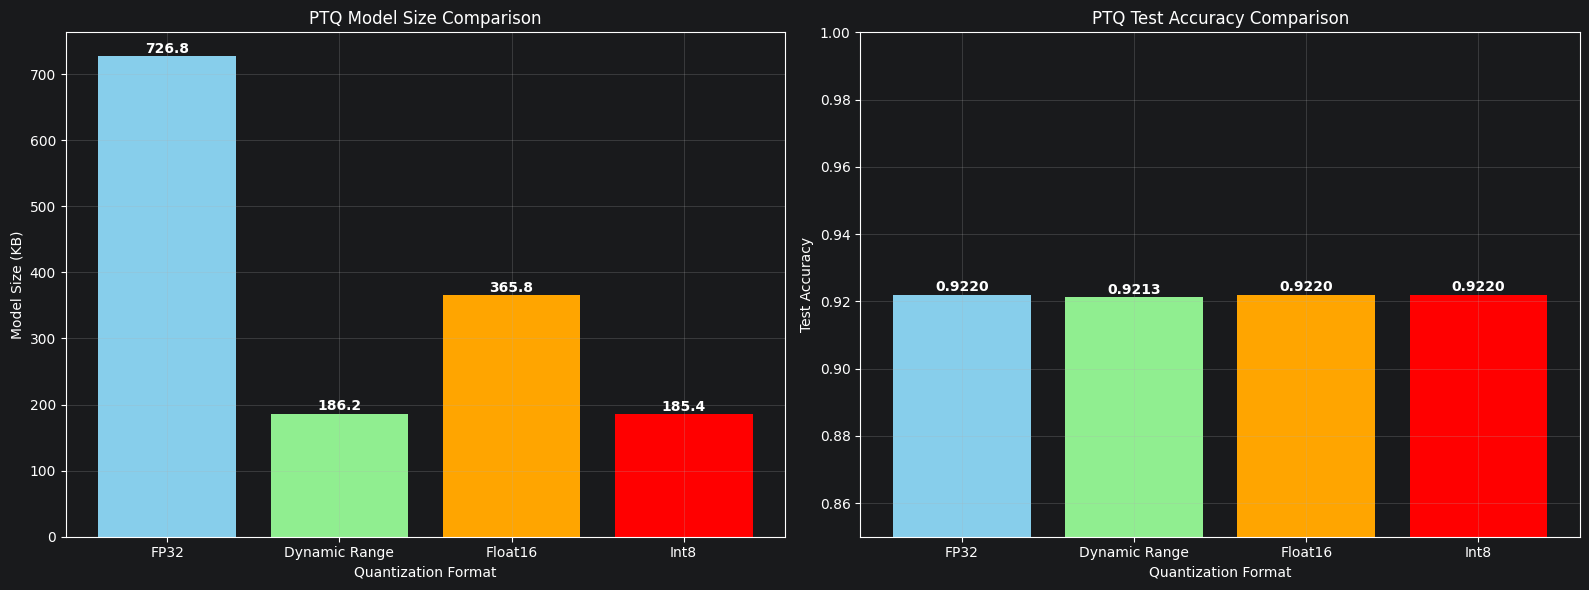

In [64]:
# Create one bar plot for model size and another for test accuracy.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for model size
axes[0].bar(ptq_comparison['Format'], ptq_comparison['Model Size (KB)'],
            color=['skyblue', 'lightgreen', 'orange', 'red'])
axes[0].set_xlabel('Quantization Format')
axes[0].set_ylabel('Model Size (KB)')
axes[0].set_title('PTQ Model Size Comparison')
axes[0].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(ptq_comparison['Model Size (KB)']):
    axes[0].text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

# Bar plot for test accuracy
axes[1].bar(ptq_comparison['Format'], ptq_comparison['Test Accuracy'],
            color=['skyblue', 'lightgreen', 'orange', 'red'])
axes[1].set_xlabel('Quantization Format')
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('PTQ Test Accuracy Comparison')
axes[1].set_ylim(0.85, 1.0)  # Set y-axis to focus on accuracy range
axes[1].grid(True, alpha=0.3)

# Add value labels on bars
for i, v in enumerate(ptq_comparison['Test Accuracy']):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


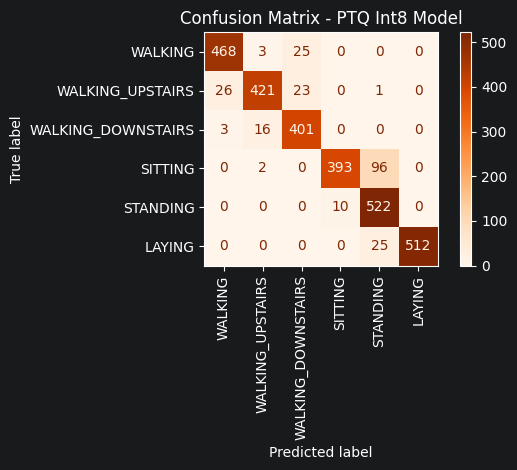

Classification Report for PTQ Int8 Model:
                    precision    recall  f1-score   support

           WALKING       0.94      0.94      0.94       496
  WALKING_UPSTAIRS       0.95      0.89      0.92       471
WALKING_DOWNSTAIRS       0.89      0.95      0.92       420
           SITTING       0.98      0.80      0.88       491
          STANDING       0.81      0.98      0.89       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.92      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.92      0.92      2947



In [65]:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.
cm_int8 = confusion_matrix(y_test, int8_pred)
disp_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_int8, display_labels=class_names)
disp_int8.plot(cmap='Oranges', values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix - PTQ Int8 Model')
plt.tight_layout()
plt.show()

print("Classification Report for PTQ Int8 Model:")
print(classification_report(y_test, int8_pred, target_names=class_names))

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [66]:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# Create quantization-aware model
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)

# Compile the QAT model
qat_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Fine-Tune the QAT Model


In [67]:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

qat_history = qat_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=8,
    batch_size=64
)

Epoch 1/8
92/92 [==============================] - 1s 4ms/step - loss: 0.0453 - accuracy: 0.9850 - val_loss: 0.1297 - val_accuracy: 0.9449
Epoch 2/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0365 - accuracy: 0.9888 - val_loss: 0.1328 - val_accuracy: 0.9483
Epoch 3/8
92/92 [==============================] - 0s 4ms/step - loss: 0.0363 - accuracy: 0.9874 - val_loss: 0.1416 - val_accuracy: 0.9477
Epoch 4/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0327 - accuracy: 0.9884 - val_loss: 0.1319 - val_accuracy: 0.9456
Epoch 5/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0318 - accuracy: 0.9893 - val_loss: 0.1688 - val_accuracy: 0.9422
Epoch 6/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0316 - accuracy: 0.9884 - val_loss: 0.1545 - val_accuracy: 0.9463
Epoch 7/8
92/92 [==============================] - 0s 3ms/step - loss: 0.0315 - accuracy: 0.9895 - val_loss: 0.1364 - val_accuracy: 0.9483
Epoch 8/8
92/92 [==========

### Evaluate the QAT Keras Model


93/93 [==============================] - 0s 1ms/step
QAT Test Accuracy: 0.9321

QAT Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.97      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.94      0.94      0.94       420
           SITTING       0.97      0.85      0.91       491
          STANDING       0.84      0.98      0.90       532
            LAYING       1.00      0.95      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



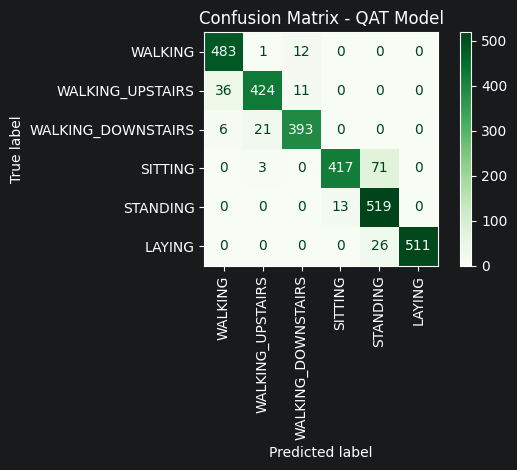

In [68]:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

qat_probs = qat_model.predict(X_test)
qat_y_pred = np.argmax(qat_probs, axis=1)
qat_test_acc = accuracy_score(y_test, qat_y_pred)
print(f"QAT Test Accuracy: {qat_test_acc:.4f}")
print(f"\nQAT Classification Report:\n{classification_report(y_test, qat_y_pred, target_names=class_names)}")

# Plot QAT confusion matrix
qat_cm = confusion_matrix(y_test, qat_y_pred)
qat_disp = ConfusionMatrixDisplay(confusion_matrix=qat_cm, display_labels=class_names)
qat_disp.plot(cmap='Greens', values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix - QAT Model')
plt.tight_layout()
plt.show()

### Convert the QAT Model to Int8 TensorFlow Lite


In [69]:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

qat_tflite_int8 = convert_to_tflite_int8(qat_model)
qat_int8_size = save_binary_model(qat_tflite_int8, "model_qat_int8.tflite")
qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_tflite_int8, X_test, y_test)
print(f"QAT Int8 Model - Size: {qat_int8_size:.2f} KB, Accuracy: {qat_int8_acc:.4f}\n")

INFO:tensorflow:Assets written to: /tmp/tmpo_89k2gn/assets


INFO:tensorflow:Assets written to: /tmp/tmpo_89k2gn/assets


QAT Int8 Model - Size: 185.81 KB, Accuracy: 0.9318



/home/whale/.venvs/tinyml-arduino/lib64/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-18 22:03:16.448422: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-18 22:03:16.448440: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-18 22:03:16.448542: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpo_89k2gn
2026-04-18 22:03:16.449906: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-18 22:03:16.449915: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpo_89k2gn
2026-04-18 22:03:16.454397: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-18 22:03:16.499289: I tensorflow/cc/saved_model/loader.cc

## 12. PTQ Int8 vs QAT Int8


In [70]:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

qat_ptq_comparison = pd.DataFrame({
    'Model': ['PTQ Int8', 'QAT Int8'],
    'Test Accuracy': [int8_acc, qat_int8_acc],
    'Model Size (KB)': [int8_size, qat_int8_size]
})
print(qat_ptq_comparison)


      Model  Test Accuracy  Model Size (KB)
0  PTQ Int8       0.921955         185.4375
1  QAT Int8       0.931795         185.8125


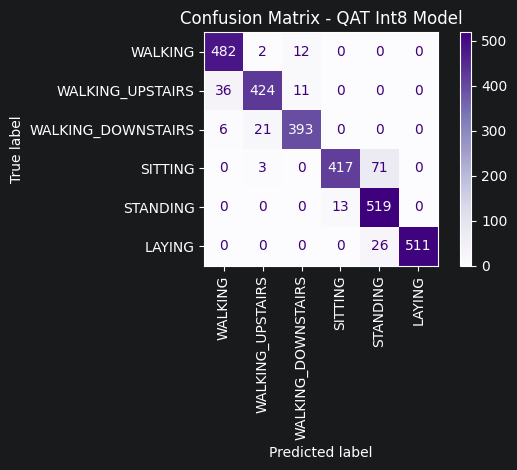

In [71]:
# Plot the confusion matrix for the QAT int8 model.

cm_qat_int8 = confusion_matrix(y_test, qat_int8_pred)
disp_qat_int8 = ConfusionMatrixDisplay(confusion_matrix=cm_qat_int8, display_labels=class_names)
disp_qat_int8.plot(cmap='Purples', values_format='d', xticks_rotation='vertical')
plt.title('Confusion Matrix - QAT Int8 Model')
plt.tight_layout()
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
    PTQ int8 has the smallest model size.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
    The QAT model gave the best accuracy. The PTQ models had very similar accuracy to each other.
3. Did QAT improve the final int8 model compared with PTQ int8?
    Yes, the QAT slightly improved the int8 model.
4. Why is this dataset a good fit for a DNN-based TinyML workflow?
    This dataset uses numerical features from sensor data, which can directly be quantized and fed into the DNN, and can be optimized for TinyML applications.
5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
    I would chooose the QAT int8 model because it has a very small size and the best accuracy.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
